In [1]:
# Week 5 
# ==========================================
# SPAM EMAIL CLASSIFIER
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("email.csv")

print("First 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nDataset Shape:")
print(df.shape)


First 5 rows:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Columns:
Index(['Category', 'Message'], dtype='object')

Dataset Shape:
(5573, 2)


In [2]:
# ==========================================
# 2. SELECT REQUIRED COLUMNS
# ==========================================

df = df[["Category", "Message"]]

# Remove missing values
df = df.dropna(subset=["Category", "Message"])

# Remove extra spaces from column values
df["Category"] = df["Category"].astype(str).str.strip().str.lower()
df["Message"] = df["Message"].astype(str).str.strip()

print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Category    0
Message     0
dtype: int64


In [3]:
# ==========================================
# 3. CHECK CATEGORY VALUES
# ==========================================

print("\nUnique Categories Before Conversion:")
print(df["Category"].unique())

# ==========================================
# 4. CONVERT CATEGORY INTO NUMBERS
# ==========================================

# ham  = 0
# spam = 1

df["Category"] = df["Category"].map({
    "ham": 0,
    "spam": 1
})


# Check if any invalid categories produced NaN
print("\nMissing Categories After Conversion:")
print(df["Category"].isna().sum())


# Remove invalid category rows
df = df.dropna(subset=["Category"])

# Convert category to integer
df["Category"] = df["Category"].astype(int)


print("\nCategory Distribution:")
print(df["Category"].value_counts())



Unique Categories Before Conversion:
['ham' 'spam' '{"mode":"full"']

Missing Categories After Conversion:
1

Category Distribution:
Category
0    4825
1     747
Name: count, dtype: int64


In [4]:
# ==========================================
# 5. SPLIT DATA
# ==========================================

X = df["Message"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", len(X_train))
print("Testing Data :", len(X_test))



Training Data: 4457
Testing Data : 1115


In [5]:
# ==========================================
# 6. TF-IDF
# ==========================================

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

# Fit only on training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)


print("\nTF-IDF Training Shape:")
print(X_train_tfidf.shape)

print("\nTF-IDF Testing Shape:")
print(X_test_tfidf.shape)



TF-IDF Training Shape:
(4457, 5000)

TF-IDF Testing Shape:
(1115, 5000)


In [6]:
# ==========================================
# 7. TRAIN NAIVE BAYES MODEL
# ==========================================

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("\nModel Training Completed!")



Model Training Completed!


In [7]:
# ==========================================
# 7. PREDICTION
# ==========================================

y_pred = model.predict(X_test_tfidf)

# Probability of spam
y_prob = model.predict_proba(X_test_tfidf)[:, 1]


In [8]:
# ==========================================
# 8. EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, zero_division=0)

recall = recall_score(y_test, y_pred, zero_division=0)

f1 = f1_score(y_test, y_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_prob)



print("\n================================")
print("       EVALUATION REPORT")
print("================================")

print("Accuracy  :", round(accuracy * 100, 2), "%")

print("Precision :", round(precision * 100, 2), "%")

print("Recall    :", round(recall * 100, 2), "%")

print("F1 Score  :", round(f1 * 100, 2), "%")

print("ROC-AUC   :", round(roc_auc, 4))



       EVALUATION REPORT
Accuracy  : 97.04 %
Precision : 100.0 %
Recall    : 77.85 %
F1 Score  : 87.55 %
ROC-AUC   : 0.9882


In [13]:
# ==========================================
# 9. CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)



Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115




Confusion Matrix:
[[966   0]
 [ 33 116]]


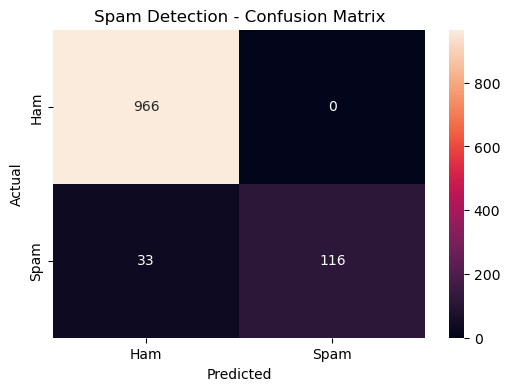

In [14]:
# ==========================================
# 10. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Detection - Confusion Matrix")

plt.show()



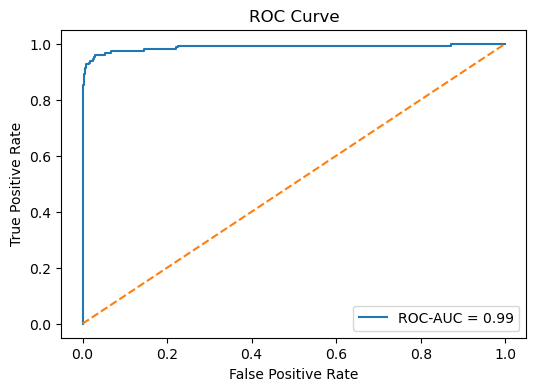

In [15]:
# ==========================================
# 11. ROC CURVE
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label="ROC-AUC = {:.2f}".format(roc_auc)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


In [16]:
# ==========================================
# 12. TEST NEW MESSAGES
# ==========================================

new_messages = [
    "Congratulations! You have won a free prize. Click now!",
    "Hi, can we meet tomorrow for the project?",
    "URGENT! You have won 10000 dollars. Claim now!",
    "Don't forget to submit your assignment today."
]

# Convert new messages into TF-IDF
new_messages_tfidf = vectorizer.transform(new_messages)

# Predict
predictions = model.predict(new_messages_tfidf)

print("\n================================")
print("       NEW MESSAGE PREDICTION")
print("================================")

for message, prediction in zip(new_messages, predictions):

    if prediction == 1:
        result = "SPAM"
    else:
        result = "NOT SPAM"

    print("\nMessage:", message)
    print("Prediction:", result)


       NEW MESSAGE PREDICTION

Message: Congratulations! You have won a free prize. Click now!
Prediction: SPAM

Message: Hi, can we meet tomorrow for the project?
Prediction: NOT SPAM

Message: URGENT! You have won 10000 dollars. Claim now!
Prediction: SPAM

Message: Don't forget to submit your assignment today.
Prediction: NOT SPAM
